In [1]:
import polars as pl

from genpp.eval import best_models

In [2]:
dfs = []
for entry in best_models:
    model_name, model_list = entry
    for model in model_list:
        dir = model.model_dir
        importance_file = dir / "permutation_importance.csv"
        if importance_file.exists():
            tag = model.tag
            df = pl.read_csv(importance_file).with_columns(
                pl.lit(model_name).alias("model_name"),
                pl.lit(tag).alias("model_tag"),
            )
            dfs.append(df)
df = pl.concat(dfs).with_columns(pl.col("model_name").replace({"chen": "LNGM"}).str.to_uppercase())

In [3]:
dfs[0]

channel_index,channel_name,category,baseline_es,permuted_es,importance,importance_std,model_name,model_tag
i64,str,str,f64,f64,f64,f64,str,str
0,"""2m_temperature+statistic_mean""","""all_var_mean""",10.534064,14.318734,0.359279,0.000133,"""chen""","""ind_es"""
1,"""10m_wind_speed+statistic_mean""","""all_var_mean""",10.534064,26.544136,1.519838,0.000087,"""chen""","""ind_es"""
2,"""10m_u_component_of_wind+statis…","""all_var_mean""",10.534064,10.680409,0.013893,0.000174,"""chen""","""ind_es"""
3,"""10m_v_component_of_wind+statis…","""all_var_mean""",10.534064,10.597652,0.006036,0.000106,"""chen""","""ind_es"""
4,"""geopotential_lev500+statistic_…","""all_var_mean""",10.534064,10.667821,0.012698,0.000168,"""chen""","""ind_es"""
…,…,…,…,…,…,…,…,…
58,"""latitude""","""meta_var""",10.534064,10.573747,0.003767,0.000143,"""chen""","""ind_es"""
59,"""longitude""","""meta_var""",10.534064,10.53409,0.000002,0.000089,"""chen""","""ind_es"""
60,"""sin_prediction_time""","""meta_var""",10.534064,10.533697,-0.000035,0.000073,"""chen""","""ind_es"""


In [4]:
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")

In [6]:
# First average importance within each (model_name, channel_name) to account for
# models with different numbers of tags, then average across models.
top_k_features = (
    df.group_by(["model_name", "channel_name"])
    .agg(pl.col("importance").mean().alias("model_mean_importance"))
    .group_by("channel_name")
    .agg(pl.col("model_mean_importance").mean().alias("mean_importance"))
    .sort("mean_importance", descending=True)
    .head(10)
    .get_column("channel_name")
    .to_list()
)

In [ ]:
df_plot = (
    df.filter(pl.col("channel_name").is_in(top_k_features))
    .with_columns(
        # prediction type from tag prefix
        pl.when(pl.col("model_tag").str.starts_with("dir_"))
        .then(pl.lit("direct"))
        .when(pl.col("model_tag").str.starts_with("ind_"))
        .then(pl.lit("indirect"))
        .otherwise(pl.lit("none"))
        .alias("prediction_type"),
        # extract loss/arch suffix, uppercased
        pl.col("model_tag").str.replace(r"^(dir|ind)_", "").str.to_uppercase().alias("_suffix"),
    )
    .with_columns(
        # build display name matching color_mapping keys
        pl.when(pl.col("model_name") == "FM")
        .then(pl.col("model_name") + "_" + pl.col("_suffix"))
        .otherwise(pl.col("model_name") + " (" + pl.col("_suffix") + ")")
        .alias("model_display_name"),
    )
    .drop("_suffix")
)

In [8]:
color_mapping = {
    "RAW": "black",
    "EMOS (ECC)": "#E65100",
    "EMOS (GCA)": "#FB8C00",
    "DRN (ECC)": "#4A148C",
    "DRN (GCA)": "#7E57C2",
    "LNGM (ES)": "#A5D6A7",
    "LNGM (PES)": "#4CAF50",
    "LNGM (MSES)": "#2E7D32",
    "LNGM (MSPES)": "#1B5E20",
    "ENGRESSION (ES)": "#BBDEFB",
    "ENGRESSION (PES)": "#42A5F5",
    "ENGRESSION (MSES)": "#1565C0",
    "ENGRESSION (MSPES)": "#0D47A1",
    "FM_UNET": "#00CED1",
    "FM_UVIT": "#F83E82",
}

hue_order = [
    "RAW",
    "EMOS (ECC)",
    "EMOS (GCA)",
    "DRN (ECC)",
    "DRN (GCA)",
    "LNGM (ES)",
    "LNGM (PES)",
    "LNGM (MSES)",
    "LNGM (MSPES)",
    "ENGRESSION (ES)",
    "ENGRESSION (PES)",
    "ENGRESSION (MSES)",
    "ENGRESSION (MSPES)",
    "FM_UNET",
    "FM_UVIT",
]

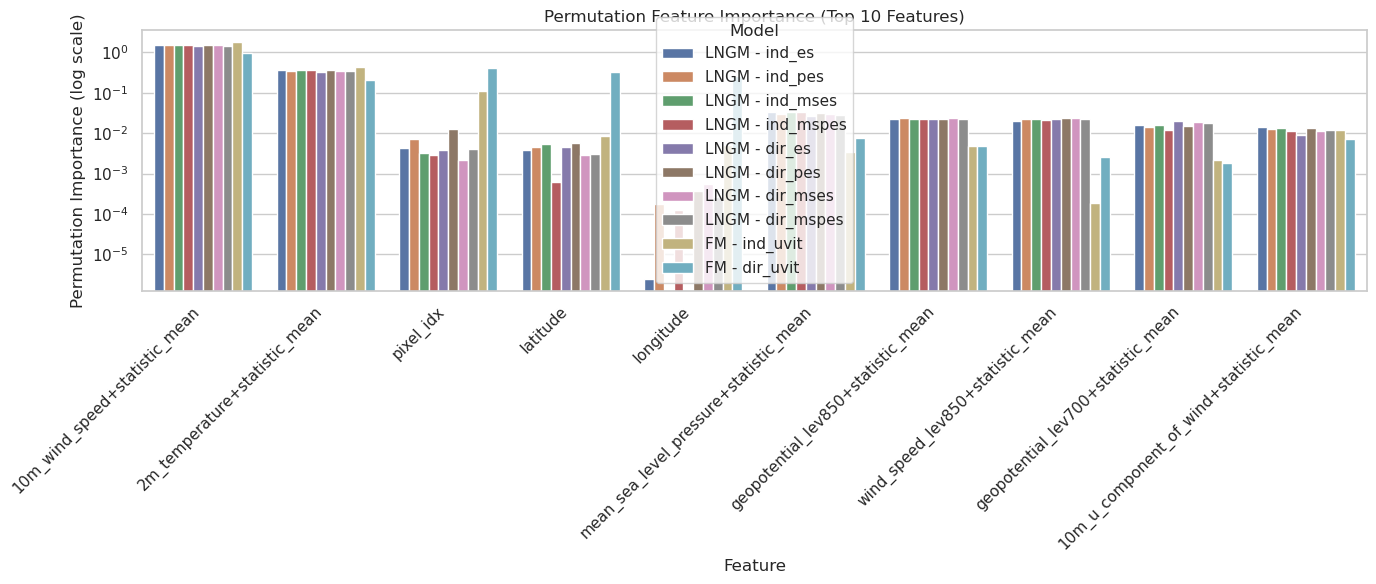

In [ ]:
import matplotlib.pyplot as plt

# Order features by mean importance (descending)
feature_order = (
    df_plot.group_by("channel_name")
    .agg(pl.col("importance").mean().alias("mean_importance"))
    .sort("mean_importance", descending=True)
    .get_column("channel_name")
    .to_list()
)

# Only keep hue entries that actually appear in the data
present_models = df_plot.get_column("model_display_name").unique().to_list()
plot_hue_order = [m for m in hue_order if m in present_models]
plot_palette = {k: v for k, v in color_mapping.items() if k in present_models}

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=df_plot.to_pandas(),
    x="channel_name",
    y="importance",
    hue="model_display_name",
    hue_order=plot_hue_order,
    palette=plot_palette,
    order=feature_order,
    ax=ax,
)
ax.set_yscale("log")
ax.set_xlabel("Feature")
ax.set_ylabel("Permutation Importance (log scale)")
ax.set_title("Permutation Feature Importance (Top 10 Features)")
ax.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
df_plot.select(pl.col("model_name").unique())

model_name
str
"""LNGM - dir_mspes"""
"""LNGM - ind_mses"""
"""LNGM - ind_pes"""
"""LNGM - ind_mspes"""
"""LNGM - dir_mses"""
"""FM - ind_uvit"""
"""LNGM - ind_es"""
"""FM - dir_uvit"""
"""LNGM - dir_pes"""
